## Import packages

In [1]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib import pyplot, transforms
from matplotlib.patches import Rectangle
import seaborn as sns
from shapely.ops import unary_union
import warnings
warnings.filterwarnings('ignore')
from pathlib import Path
parent_dir = Path.cwd().parent.parent.parent

"""
This code is used for Fig4.G-H.accessibility and equity across U.S. regions segmented by urban and rural areas. 
"""

'\nThis code is used for Fig4.G-H.accessibility and equity across U.S. regions segmented by urban and rural areas. \n'

## Data Processing

data source: https://data.ess.tsinghua.edu.cn/  
global hierarchical urban boundaries (GHUB)

In [2]:
def load_map_data():
    """
    Load US map data and urban boundary data
    """
    # Read US map data
    usa_map_file = parent_dir / 'data' / 'US-map'/ 'usa_map.geojson'
    gdf1 = gpd.read_file(usa_map_file)
    gdf1 = gdf1[['GID_0', 'GID_1', 'GID_2', 'COUNTRY', 'NAME_1', 'NAME_2', 'geometry']]
    
    # Read urban boundary data
    file_path = parent_dir / 'data' / 'US-map' / 'GHUB2018_gpkg'/ 'GHUB2018.gpkg'
    gdf = gpd.read_file(file_path)
    
    return gdf1, gdf

def processing_acc_data(year, area, type = 'population-based'):
    """
    Process accessibility data for specific year and urban/rural classification
    """
    # Read charging station accessibility data
    if type == 'population-based':
        acc_file = parent_dir / 'data' / 'US-accessibility' / 'population-based' / f'{area}' / f'{year}' / f'{year}_city_accessibility_summaries_evse_count.csv'
    elif type == 'facility-based':
        acc_file = parent_dir / 'data' / 'US-accessibility' / 'facility-based' / f'{area}' / f'{year}' / f'{year}_accessibility_summary_evse_num.csv'
    acc_data = pd.read_csv(acc_file)
    
    # Add urban/rural classification and year columns
    acc_data['ur'] = area
    acc_data['Year'] = str(year)
    acc_data = acc_data.fillna(0)
    
    return acc_data

def combine_accessibility_data(matched_gdf_2014, matched_gdf_2019, matched_gdf_2024):
    """
    Combine accessibility data from three years and calculate growth rates
    """
    # Merge three DataFrames and add 'Year' column
    combined_df = pd.concat([
        matched_gdf_2014.assign(Year=2014),
        matched_gdf_2019.assign(Year=2019),
        matched_gdf_2024.assign(Year=2024),
    ])
    
    # Use pivot to transform accessibility data from different years into columns
    merged_df = combined_df.pivot_table(
        index='GID_2',
        columns='Year',
        values='Average_Accessibility',
        aggfunc='mean'
    ).reset_index()
    
    # Rename columns
    merged_df.columns = ['GID_2', 'Accessibility_2014', 'Accessibility_2019', 'Accessibility_2024']
    
    # Merge urban/rural classification information
    urban_rural_info = matched_gdf_2014[['GID_2', 'ur']]
    merged_df = pd.merge(merged_df, urban_rural_info, on='GID_2')

    # Calculate growth rates with zero-division protection
    merged_df['Growth1'] = np.where(
        merged_df['Accessibility_2014'] != 0,
        ((merged_df['Accessibility_2019'] - merged_df['Accessibility_2014']) / merged_df['Accessibility_2014']) * 100,
        np.nan
    )

    merged_df['Growth2'] = np.where(
        merged_df['Accessibility_2019'] != 0,
        ((merged_df['Accessibility_2024'] - merged_df['Accessibility_2019']) / merged_df['Accessibility_2019']) * 100,
        np.nan
    )
    
    # Fill NaN values with 0
    merged_df = merged_df.fillna(0)
    
    # Aggregate growth rates by urban/rural classification
    merge_group1 = merged_df.groupby(['ur'])['Growth1'].median()
    merge_group2 = merged_df.groupby(['ur'])['Growth2'].median()
    
    return merge_group1, merge_group2

def growth_p():
    """
    Main function to execute the accessibility analysis
    """
    # Load map data
    gdf1, gdf = load_map_data()
    
    # Process urban accessibility data
    matched_gdf_2014_urban = processing_acc_data(2014, 'urban')
    matched_gdf_2019_urban = processing_acc_data(2019, 'urban')
    matched_gdf_2024_urban = processing_acc_data(2024, 'urban')
    
    # Process rural accessibility data
    matched_gdf_2014_rural = processing_acc_data(2014, 'rural')
    matched_gdf_2019_rural = processing_acc_data(2019, 'rural')
    matched_gdf_2024_rural = processing_acc_data(2024, 'rural')
    
    # Combine and analyze urban accessibility data
    urban_growth_2014_2019, urban_growth_2019_2024 = combine_accessibility_data(
        matched_gdf_2014_urban, matched_gdf_2019_urban, matched_gdf_2024_urban
    )

    rural_growth_2014_2019, rural_growth_2019_2024 = combine_accessibility_data(
        matched_gdf_2014_rural, matched_gdf_2019_rural, matched_gdf_2024_rural
    )
    
    print("Urban Growth Rates:")
    print(urban_growth_2014_2019, urban_growth_2019_2024)
    print("\nRural Growth Rates:")
    print(rural_growth_2014_2019, rural_growth_2019_2024)
    return urban_growth_2014_2019, urban_growth_2019_2024, rural_growth_2014_2019, rural_growth_2019_2024 

def growth_f():
    """
    Main function to execute the accessibility analysis
    """
    # Load map data
    gdf1, gdf = load_map_data()
    
    # Process urban accessibility data
    matched_gdf_2014_urban = processing_acc_data(2014, 'urban', type = 'facility-based')
    matched_gdf_2019_urban = processing_acc_data(2019, 'urban', type = 'facility-based')
    matched_gdf_2024_urban = processing_acc_data(2024, 'urban', type = 'facility-based')
    
    # Process rural accessibility data
    matched_gdf_2014_rural = processing_acc_data(2014, 'rural', type = 'facility-based')
    matched_gdf_2019_rural = processing_acc_data(2019, 'rural', type = 'facility-based')
    matched_gdf_2024_rural = processing_acc_data(2024, 'rural', type = 'facility-based')
    
    # Combine and analyze urban accessibility data
    urban_growth_2014_2019, urban_growth_2019_2024 = combine_accessibility_data(
        matched_gdf_2014_urban, matched_gdf_2019_urban, matched_gdf_2024_urban
    )

    rural_growth_2014_2019, rural_growth_2019_2024 = combine_accessibility_data(
        matched_gdf_2014_rural, matched_gdf_2019_rural, matched_gdf_2024_rural
    )
    
    print("Urban Growth Rates:")
    print(urban_growth_2014_2019, urban_growth_2019_2024)
    print("\nRural Growth Rates:")
    print(rural_growth_2014_2019, rural_growth_2019_2024)
    return urban_growth_2014_2019, urban_growth_2019_2024, rural_growth_2014_2019, rural_growth_2019_2024 

## Mapping and Visualization¶

In [3]:
def merge_geometries_by_attribute(gdf, groupby_column='NAME_1', crs=4326):
    """
    Merge geometries in a GeoDataFrame by grouping them based on a specified attribute column.
    """
    # Dictionary to store merged geometries
    merged_geometries = {}
    
    # Group by specified column and merge geometries for each group
    for name, group in gdf.groupby(groupby_column):
        # Use unary_union to merge multiple polygons into one (if overlaps exist)
        # If only one geometry exists in group, use it directly
        if group['geometry'].size > 1:
            merged_geom = unary_union(group['geometry'].tolist())
        else:
            merged_geom = group['geometry'].iloc[0]
        merged_geometries[name] = merged_geom
    
    # Create new DataFrame to store merged results
    merged_df = pd.DataFrame.from_dict(merged_geometries, orient='index', columns=['geometry'])
    merged_gdf = gpd.GeoDataFrame(merged_df, geometry='geometry')
    
    # Add original grouping column as attribute column
    merged_gdf[groupby_column] = merged_gdf.index
    
    # Reset index to get clean sequential indexing
    merged_gdf.reset_index(drop=True, inplace=True)
    
    # Set Coordinate Reference System for the output GeoDataFrame
    merged_gdf_with_crs = merged_gdf.set_crs(epsg=crs)
    
    return merged_gdf_with_crs

In [4]:
def plot_urban_rural_growth(rural_growth_p1, rural_growth_p2,urban_growth_p1, urban_growth_p2, 
                            figsize=(4, 2), ylim=(-5, 160)):
    """
    Plot urban vs. rural growth rates with arrows.
    """
    # Create a DataFrame from input data
    growth_data = {
        'ur': ['rural','urban'],
        'Growth_Rate1': [rural_growth_p1,urban_growth_p1],
        'Growth_Rate2': [rural_growth_p2,urban_growth_p2]
    }
    growth_df = pd.DataFrame(growth_data)
    
    # Initialize figure and axis
    fig, ax = plt.subplots(figsize=figsize)
    
    # Define background colors (RGBA format with transparency)
    bg_colors = {
        'rural': (1.0, 0.4, 0.4, 0.1),  # light red
        'urban': (0.4, 0.4, 1.0, 0.1)   # light blue
    }
    
    # Draw background rectangles
    for i, ur_type in enumerate(['rural','urban']):
        ax.add_patch(Rectangle(
            (i - 0.5, ylim[0]),
            width=1, height=ylim[1] - ylim[0],
            facecolor=bg_colors[ur_type],
            edgecolor='none', zorder=-1
        ))
    
    # Plot the two growth points (white dots)
    sns.stripplot(
        data=growth_df.melt(id_vars='ur', var_name='Type', value_name='Rate'),
        x='ur',
        y='Rate',
        order=['rural', 'urban'],
        palette={'urban': 'white', 'rural': 'white'},
        size=8,
        edgecolor='black',
        linewidth=1,
        jitter=False,
        ax=ax
    )
    
    # Add arrows connecting the two growth points
    for i, ur_type in enumerate(['rural','urban']):
        rate1 = growth_df[growth_df['ur'] == ur_type]['Growth_Rate1'].values[0]
        rate2 = growth_df[growth_df['ur'] == ur_type]['Growth_Rate2'].values[0]
        
        ax.annotate(
            '', xy=(i, rate2), xytext=(i, rate1),
            arrowprops=dict(
                arrowstyle='->', 
                color='green', 
                lw=2,
                shrinkA=0, shrinkB=0
            ),
            zorder=10
        )
        
        # Add text labels for the rates
        ax.text(i + 0.05, rate1, f'{rate1:.2f}%', ha='left', va='center', fontsize=11)
        ax.text(i + 0.05, rate2, f'{rate2:.2f}%', ha='left', va='center', fontsize=11)
    
    # Add dashed line between urban and rural
    ax.axvline(x=0.5, color='gray', linestyle='--', linewidth=1, alpha=0.5)
    ax.axvline(x=1.5, color='gray', linestyle='--', linewidth=1, alpha=0.5)

    # Customize axes
    ax.set_ylim(ylim[0], ylim[1])
    ax.set_ylabel(r'$\bf{Growth\ (\%)}$', fontsize=15)
    ax.set_xticklabels(['rural','urban'], fontsize=10)
    ax.set_xlabel('')
    ax.set_xticks([])  # Hide tick marks
    
    plt.tight_layout()
    return fig, ax

In [5]:
def plot_accessibility_boxplots(
    matched_gdf_2014_urban, matched_gdf_2014_rural,
    matched_gdf_2019_urban, matched_gdf_2019_rural,
    matched_gdf_2024_urban, matched_gdf_2024_rural, type = 'population-based',
    figsize=(4, 4), ylim=(-5, 1500)
):
    """
    Plot boxplots of average accessibility for urban and rural counties across years.
    """
    # Combine all DataFrames
    combined_df = pd.concat([
        matched_gdf_2014_urban, matched_gdf_2014_rural,
        matched_gdf_2019_urban, matched_gdf_2019_rural,
        matched_gdf_2024_urban, matched_gdf_2024_rural
    ]).reset_index(drop=True)

    # Standardize 'ur' column labels
    combined_df['ur'] = combined_df['ur'].replace({
        'urban': 'Urban',
        'rural': 'Rural'
    })

    # Create figure
    fig, ax = plt.subplots(figsize=figsize)

    # Define background colors (RGBA format, with transparency)
    bg_colors = {
        'Urban': (1.0, 0.4, 0.4, 0.1),  # light red
        'Rural': (0.4, 0.4, 1.0, 0.1)   # light blue
    }

    # Draw background rectangles for each group
    for i, group in enumerate(['Urban', 'Rural']):
        ax.add_patch(Rectangle(
            (i - 0.5, ylim[0]),  # bottom-left corner
            width=1, height=ylim[1] - ylim[0],  # cover full height
            facecolor=bg_colors[group],
            edgecolor='none',
            zorder=-1  # keep behind the boxes
        ))

    # Draw boxplots
    sns.boxplot(
        data=combined_df,
        x='ur',
        y='Average_Accessibility',
        hue='Year',
        palette={'2014': 'orangered', '2019': 'teal', '2024': 'dodgerblue'},
        width=0.5,
        dodge=True,
        gap=0.3,
        order=['Rural', 'Urban'],
        flierprops={
            'marker': 'o',
            'markerfacecolor': 'white',
            'markeredgecolor': 'white',
            'markersize': 1.5
        },
        medianprops={
            'color': 'orange',
            'linewidth': 2,
            'linestyle': '--'
        },
        ax=ax
    )

    # Add dashed separator lines
    ax.axvline(x=0.5, color='gray', linestyle='--', linewidth=1, alpha=0.5)
    ax.axvline(x=1.5, color='gray', linestyle='--', linewidth=1, alpha=0.5)

    # Set axis limits and labels
    ax.set_ylim(ylim)
    ax.set_xlabel(r'$\bf{Counties\ by\ Urban\ or\ Rural}$', fontsize=15, labelpad=8)
     # Read charging station accessibility data
    if type == 'population-based':
        ax.set_ylabel(r'$\bf{Population-based\ Acc.}$', fontsize=15) 
    elif type == 'facility-based':
        ax.set_ylabel(r'$\bf{Facility-based\ Acc.}$', fontsize=15)
    

    # Remove default legend (optional if you plan to add a custom one)
    if ax.get_legend() is not None:
        ax.legend_.remove()

    plt.tight_layout()
    plt.show()
    return fig, ax


In [6]:
def plot_urban_counties_map(usa_map_gdf, merged_gdf, urban_counties):
    """
    Plot a map showing urban counties within the U.S. using an Albers projection.
    """

    # Define the coordinate reference system (CRS)
    albers_proj = '+proj=aea +lat_1=20 +lat_2=60 +lon_0=0'

    # Define fonts
    font1 = {'family': 'Arial', 'style': 'italic', 'weight': 'normal', 'color': 'black', 'size': 6}
    font2 = {'family': 'Arial', 'weight': 'normal', 'size': 6}
    font3 = {'family': 'fantasy', 'weight': 'bold', 'color': 'teal'}

    # Set up figure
    fig, ax = plt.subplots(figsize=(10, 6), dpi=150)

    # Adjust global legend styles
    plt.rcParams['legend.labelspacing'] = 0.8
    plt.rcParams['legend.title_fontsize'] = 8

    # Apply rotation transform (optional for projection styling)
    base = pyplot.gca().transData
    rot = transforms.Affine2D().rotate_deg(60)

    # Plot base U.S. map (light gray background)
    ax = usa_map_gdf.to_crs(albers_proj).plot(
        ax=ax,
        facecolor='lightgrey',
        edgecolor='thistle',
        linewidth=0.5,
        alpha=0.2,
        zorder=10,
        transform=rot + base
    )
    ax = merged_gdf.to_crs(albers_proj).plot(
        ax=ax,facecolor='lightgrey', 
        edgecolor='black', linewidth = 0.5, alpha=0.2,zorder = 10,transform = rot+base)

    # Plot urban counties (highlighted)
    urban_counties = gpd.overlay(urban_counties, usa_map_gdf, how='intersection')

    ax = urban_counties.to_crs(albers_proj).plot(
        ax=ax,
        facecolor='salmon',
        edgecolor='lightgray',
        linewidth=0.15,
        legend_kwds={
            'loc': 'lower right',
            'title': 'Urban Counties',
            'shadow': False,
            'prop': font2
        },
        zorder=2,
        transform=rot + base
    )
    ax.set_ylim(-3600000,0)
    ax.set_xlim(-12800000,-7300000)
    # Remove axis ticks and labels
    ax.axis('off')

    plt.tight_layout()
    plt.show()
    return fig, ax


## Test Run Growth Rate

Urban Growth Rates:
ur
urban    45.812893
Name: Growth1, dtype: float64 ur
urban    125.138537
Name: Growth2, dtype: float64

Rural Growth Rates:
ur
rural    0.0
Name: Growth1, dtype: float64 ur
rural    0.0
Name: Growth2, dtype: float64
Urban Growth Rates:
ur
urban    0.301985
Name: Growth1, dtype: float64 ur
urban    67.437792
Name: Growth2, dtype: float64

Rural Growth Rates:
ur
rural    0.0
Name: Growth1, dtype: float64 ur
rural    0.0
Name: Growth2, dtype: float64


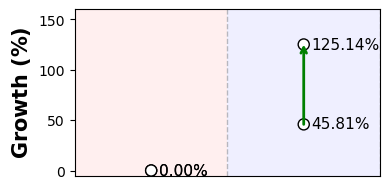

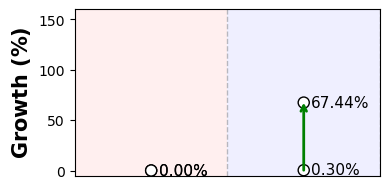

In [7]:
if __name__ == "__main__":
    urban_growth_p1, urban_growth_p2, rural_growth_p1, rural_growth_p2  = growth_p()
    urban_growth_f1, urban_growth_f2, rural_growth_f1, rural_growth_f2  = growth_f()

    plot_urban_rural_growth(rural_growth_p1[0], rural_growth_p2[0],urban_growth_p1[0], urban_growth_p2[0])
    plot_urban_rural_growth(rural_growth_f1[0], rural_growth_f2[0],urban_growth_f1[0], urban_growth_f2[0])

## Test Run Boxplot

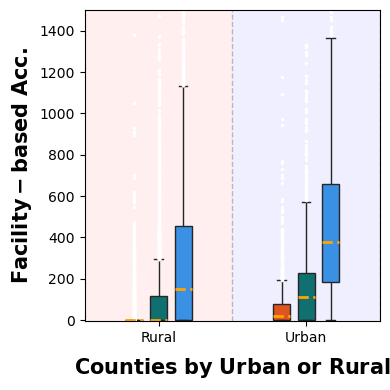

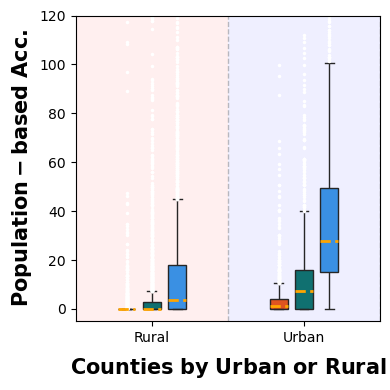

In [8]:
if __name__ == "__main__":
    
    plot_accessibility_boxplots(
        processing_acc_data(2014, 'urban',type = 'facility-based')[['Average_Accessibility', 'ur', 'Year']], processing_acc_data(2014, 'rural',type = 'facility-based')[['Average_Accessibility', 'ur', 'Year']],
        processing_acc_data(2019, 'urban',type = 'facility-based')[['Average_Accessibility', 'ur', 'Year']], processing_acc_data(2019, 'rural',type = 'facility-based')[['Average_Accessibility', 'ur', 'Year']],
        processing_acc_data(2024, 'urban',type = 'facility-based')[['Average_Accessibility', 'ur', 'Year']], processing_acc_data(2024, 'rural',type = 'facility-based')[['Average_Accessibility', 'ur', 'Year']],
        type = 'facility-based', figsize=(4, 4), ylim=(-5, 1500))
    
    
    plot_accessibility_boxplots(
        processing_acc_data(2014, 'urban')[['Average_Accessibility', 'ur', 'Year']], processing_acc_data(2014, 'rural')[['Average_Accessibility', 'ur', 'Year']],
        processing_acc_data(2019, 'urban')[['Average_Accessibility', 'ur', 'Year']], processing_acc_data(2019, 'rural')[['Average_Accessibility', 'ur', 'Year']],
        processing_acc_data(2024, 'urban')[['Average_Accessibility', 'ur', 'Year']], processing_acc_data(2024, 'rural')[['Average_Accessibility', 'ur', 'Year']],
        figsize=(4, 4), ylim=(-5, 120))

## Test Run Map

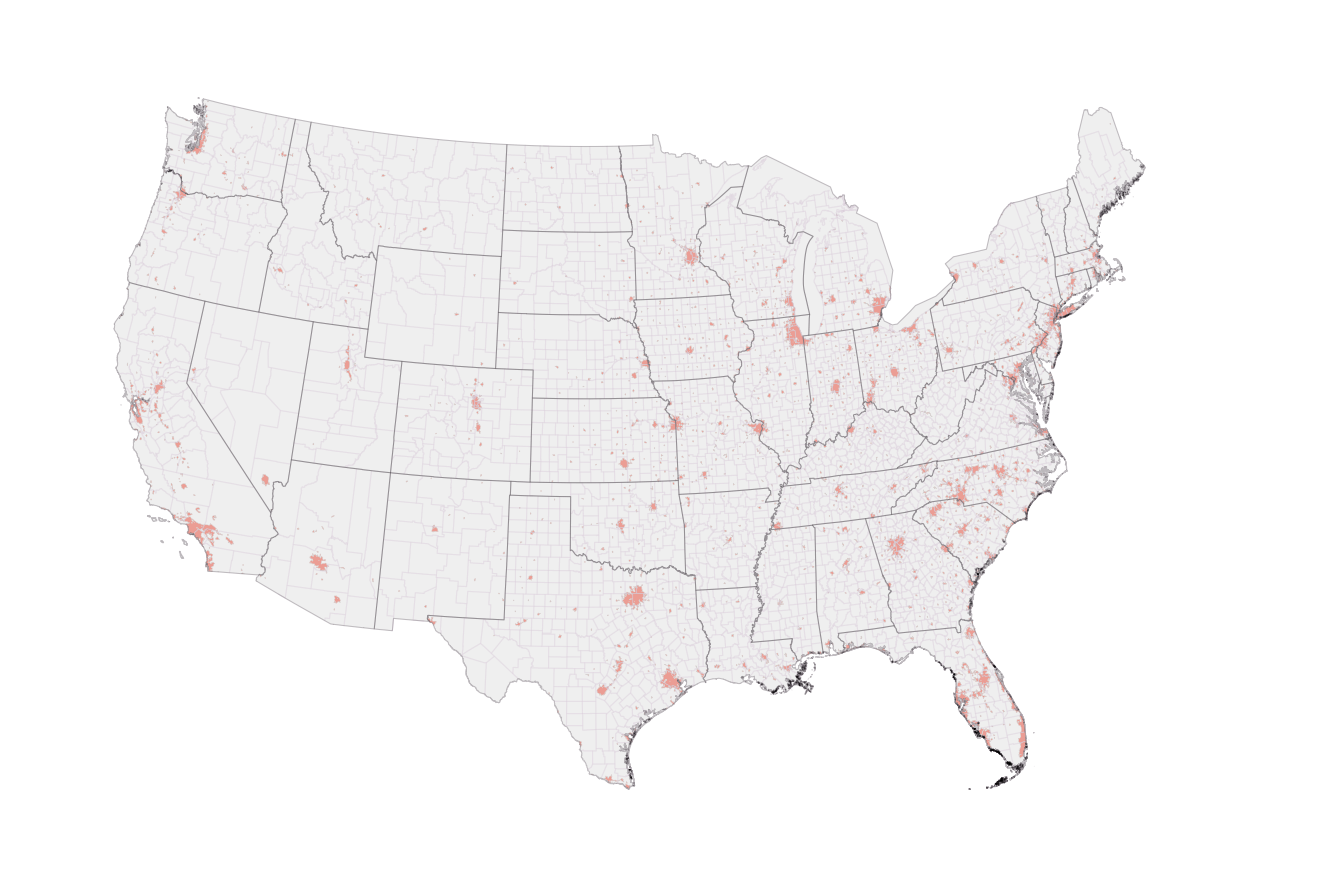

In [9]:
if __name__ == "__main__":

    # load data
    gdf1, gdf = load_map_data()
    merged_gdf = merge_geometries_by_attribute(gdf1, 'GID_1')

    plot_urban_counties_map( gdf1, merged_gdf, gdf)